<a href="https://colab.research.google.com/github/ep24b009-HariccharanM/Coding-Exercises/blob/main/Hartree_Fock_Infinitewell-1D/Hartree_Fock_Infinitewell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This cell is performing integration to find all possible two electron integrals.
import numpy as np

# 1. Setup Parameters
a = 0.001
N = 25

# 2. Vectorized Gauss-Legendre Quadrature Setup
# Using 256 points per dimension is incredibly accurate for trigonometric functions
deg = 256
x_nodes, w_nodes = np.polynomial.legendre.leggauss(deg)
# Map nodes from [-1, 1] to [0, 1]
x = 0.5 * (x_nodes + 1)
w = 0.5 * w_nodes

# Pre-calculate all sine variations on the grid to avoid redundant math
# Shape will be (10, 64) -> row i-1 contains sin(i * pi * x)
sin_grid = np.array([np.sqrt(2)*np.sin(m * np.pi * x) for m in range(1, N + 1)])

# Create 2D coordinate matrices for x1 and x2
X1, X2 = np.meshgrid(x, x, indexing='ij')
W1, W2 = np.meshgrid(w, w, indexing='ij')

# Pre-calculate the denominator grid: 1 / (a + |x1 - x2|)
# Shape is (256,256)
inv_den = 10**(3) / (a + np.abs(X1 - X2))
# Incorporate integration weights directly into the kernel
kernel = inv_den * W1 * W2

# Initialize empty matrix
result_matrix = np.zeros((N, N, N, N))

# 3. Calculate using Loops with Symmetry
# We iterate through all combinations of i, j, k, l
for i in range(1, N + 1):
    for j in range(1, N + 1):
        # Symmetry optimization: sin(i*pi*x)*sin(j*pi*x) is symmetric under i <-> j
        if j < i:
            result_matrix[i-1, j-1, :, :] = result_matrix[j-1, i-1, :, :]
            continue

        f1 = sin_grid[i-1] * sin_grid[j-1]  # 1D array of length 256

        for k in range(1, N + 1):
            for l in range(1, N + 1):
                # Symmetry optimization: sin(k*pi*x)*sin(l*pi*x) is symmetric under k <-> l
                if l < k:
                    result_matrix[i-1, j-1, k-1, l-1] = result_matrix[i-1, j-1, l-1, k-1]
                    continue

                f2 = sin_grid[k-1] * sin_grid[l-1]  # 1D array of length 256

                # Outer product gives the 2D numerator grid (256,256))
                numerator_2d = np.outer(f1, f2)

                # Double integral is now a fast element-wise matrix multiplication and sum
                integral_val = np.sum(numerator_2d * kernel)

                result_matrix[i-1, j-1, k-1, l-1] = integral_val


G = result_matrix

In [ ]:
# This cell is for 1 electron integral
H = np.zeros((N,N))
for i in range(0,N):
  H[i,i] = 0.5* ((i+1)*np.pi)**2

# **2 ELECTRON CASE**

In [ ]:
# Initializing : We can take the initial molecular orbitals to be same as atomic orbitals.
max_iter = 200
N = 2 # Number of electrons
K = 25 # Number of orbitals

C = np.eye(K) #Molecular orbital- Basis relating matrix

In [ ]:
# Hartree fock execution

for iter in range(max_iter):
  F = np.zeros((K,K))
  D = np.zeros((K,K))     #Density matrix

  for i in range(K):
    for j in range(K):
      for k in range(int(N/2)):
        D[i,j] += 2*C[i,k]*C[j,k]

  for i in range(K):
    for j in range(K):
      s = 0

      for k in range(K):
        for l in range(K):
          s += (G[i,j,k,l] - 0.5*G[i,l,k,j])*D[l,k]

      F[i,j] = H[i,j] + s

  epsilon_unarranged, C_unarranged = np.linalg.eigh(F)

  # 1. Get the index positions that would sort the eigenvalues in ascending order
  idx = np.argsort(epsilon_unarranged)

  # 2. Re-order both eigenvalues and eigenvectors using those indices
  epsilon = epsilon_unarranged[idx]
  C = C_unarranged[:, idx]  # Crucial: sort the COLUMNS of C

C222 = C # Saving the value

E_elec_22 = 0.5* np.trace(np.dot(D , H+F))
print("The final energy is",E_elec_22)

The final energy is 14626.958202615944


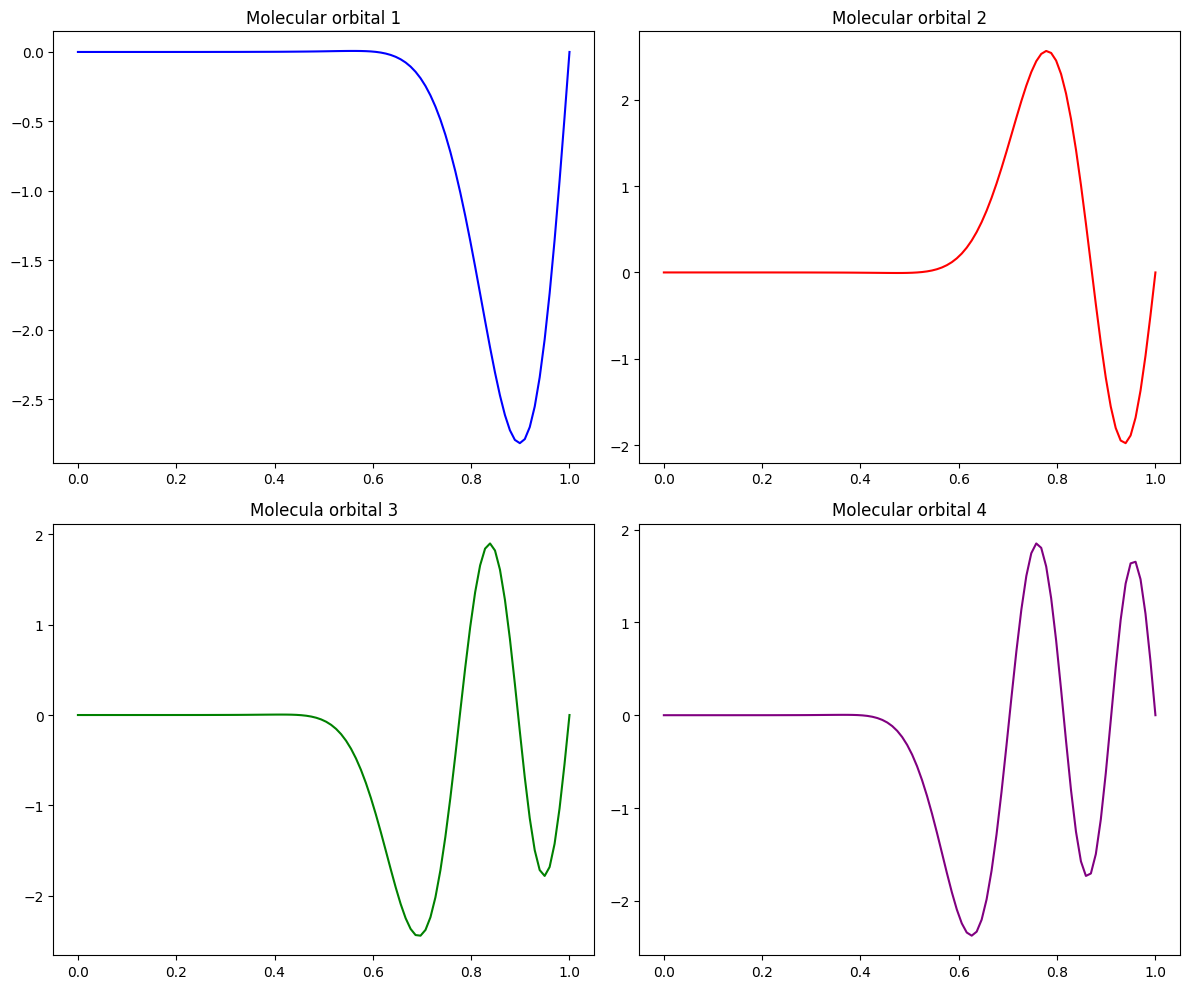

In [ ]:
import matplotlib.pyplot as plt

def mo_1(x):
  y = 0
  for i in range(K):
    y += C222[i,0]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_2(x):
  y = 0
  for i in range(K):
    y += C222[i,1]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_3(x):
  y = 0
  for i in range(K):
    y += C222[i,2]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_4(x):
  y = 0
  for i in range(K):
    y += C222[i,3]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(x, mo_1(x), color='blue')
axs[0, 0].set_title('Molecular orbital 1')

axs[0, 1].plot(x, mo_2(x), color='red')
axs[0, 1].set_title('Molecular orbital 2')

axs[1, 0].plot(x, mo_3(x), color='green')
axs[1, 0].set_title('Molecula orbital 3')

axs[1, 1].plot(x, mo_4(x), color='purple')
axs[1, 1].set_title('Molecular orbital 4')

plt.tight_layout()
plt.show()

# **4 electron case**

In [ ]:
# Initializing : We can take the initial molecular orbitals to be same as atomic orbitals.
max_iter = 200
N = 4 # Number of electrons
K = 25 # Number of orbitals

C = np.eye(K) #Molecular orbital- Basis relating matrix

In [ ]:
# Hartree fock execution

for iter in range(max_iter):
  F = np.zeros((K,K))
  D = np.zeros((K,K))     #Density matrix

  for i in range(K):
    for j in range(K):
      for k in range(int(N/2)):
        D[i,j] += 2*C[i,k]*C[j,k]

  for i in range(K):
    for j in range(K):
      s = 0

      for k in range(K):
        for l in range(K):
          s += (G[i,j,k,l] - 0.5*G[i,l,k,j])*D[l,k]

      F[i,j] = H[i,j] + s

  epsilon_unarranged, C_unarranged = np.linalg.eigh(F)

  # 1. Get the index positions that would sort the eigenvalues in ascending order
  idx = np.argsort(epsilon_unarranged)

  # 2. Re-order both eigenvalues and eigenvectors using those indices
  epsilon = epsilon_unarranged[idx]
  C = C_unarranged[:, idx]  # Crucial: sort the COLUMNS of C

C444 = C # Saving the value

E_elec_44 = 0.5* np.trace(np.dot(D , H+F))
print("The final energy is",E_elec_44)

The final energy is 45631.12639200657


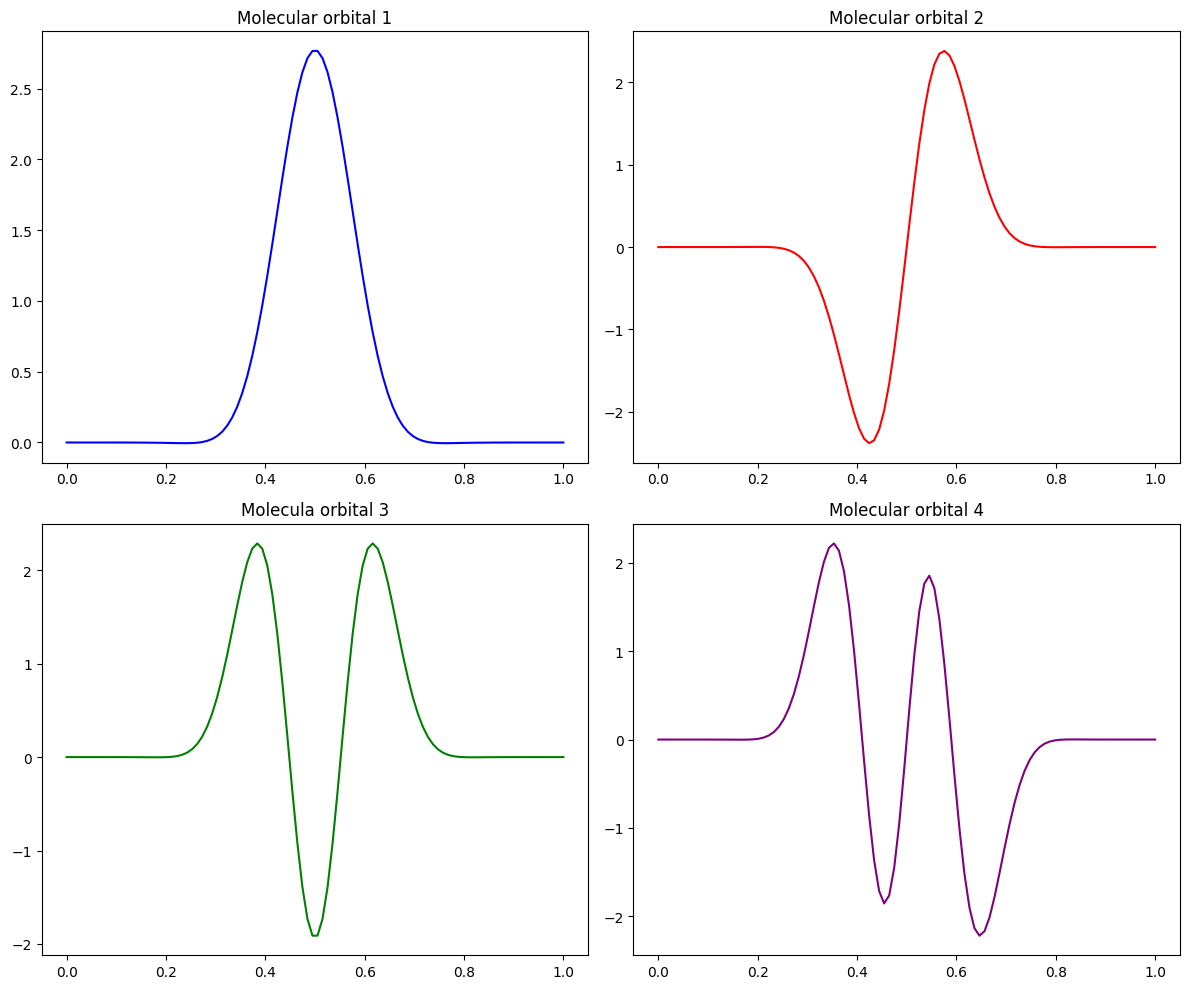

In [ ]:
import matplotlib.pyplot as plt

def mo_1(x):
  y = 0
  for i in range(K):
    y += C444[i,0]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_2(x):
  y = 0
  for i in range(K):
    y += C444[i,1]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_3(x):
  y = 0
  for i in range(K):
    y += C444[i,2]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_4(x):
  y = 0
  for i in range(K):
    y += C444[i,3]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(x, mo_1(x), color='blue')
axs[0, 0].set_title('Molecular orbital 1')

axs[0, 1].plot(x, mo_2(x), color='red')
axs[0, 1].set_title('Molecular orbital 2')

axs[1, 0].plot(x, mo_3(x), color='green')
axs[1, 0].set_title('Molecula orbital 3')

axs[1, 1].plot(x, mo_4(x), color='purple')
axs[1, 1].set_title('Molecular orbital 4')

plt.tight_layout()
plt.show()

# **6 Electron case**

In [ ]:
# Initializing : We can take the initial molecular orbitals to be same as atomic orbitals.
max_iter = 200
N = 6 # Number of electrons
K = 25 # Number of orbitals

C = np.eye(K) #Molecular orbital- Basis relating matrix

In [ ]:
# Hartree fock execution

for iter in range(max_iter):
  F = np.zeros((K,K))
  D = np.zeros((K,K))     #Density matrix

  for i in range(K):
    for j in range(K):
      for k in range(int(N/2)):
        D[i,j] += 2*C[i,k]*C[j,k]

  for i in range(K):
    for j in range(K):
      s = 0

      for k in range(K):
        for l in range(K):
          s += (G[i,j,k,l] - 0.5*G[i,l,k,j])*D[l,k]

      F[i,j] = H[i,j] + s

  epsilon_unarranged, C_unarranged = np.linalg.eig(F)

  # 1. Get the index positions that would sort the eigenvalues in ascending order
  idx = np.argsort(epsilon_unarranged)

  # 2. Re-order both eigenvalues and eigenvectors using those indices
  epsilon = epsilon_unarranged[idx]
  C = C_unarranged[:, idx]  # Crucial: sort the COLUMNS of C

C666 = C # Saving the value

E_elec_66 = 0.5* np.trace(np.dot(D , H+F))
print("The final energy is",E_elec_66)

The final energy is 114121.2797183197


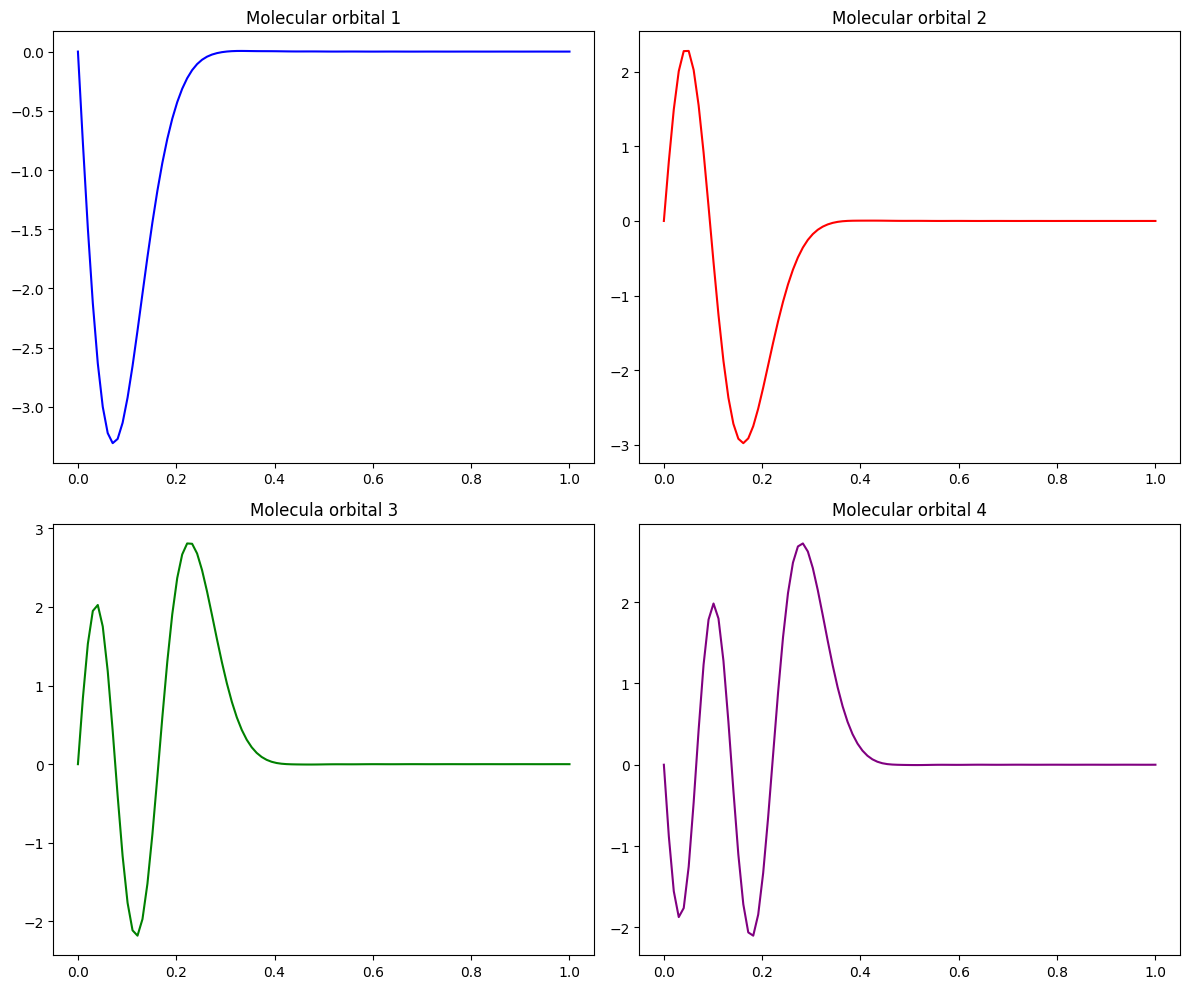

In [ ]:
import matplotlib.pyplot as plt

def mo_1(x):
  y = 0
  for i in range(K):
    y += C666[i,0]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_2(x):
  y = 0
  for i in range(K):
    y += C666[i,1]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_3(x):
  y = 0
  for i in range(K):
    y += C666[i,2]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

def mo_4(x):
  y = 0
  for i in range(K):
    y += C666[i,3]*2**0.5*np.sin((i+1)*np.pi*x)
  return y

x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(x, mo_1(x), color='blue')
axs[0, 0].set_title('Molecular orbital 1')

axs[0, 1].plot(x, mo_2(x), color='red')
axs[0, 1].set_title('Molecular orbital 2')

axs[1, 0].plot(x, mo_3(x), color='green')
axs[1, 0].set_title('Molecula orbital 3')

axs[1, 1].plot(x, mo_4(x), color='purple')
axs[1, 1].set_title('Molecular orbital 4')

plt.tight_layout()
plt.show()

**Saving results from 4 electron case**

In [ ]:
np.save('Hartree_Fock_results.npy', C444)